# Load the required Libraries

In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load tha data

In [13]:
df=pd.read_csv(r'C:\Users\pc\Downloads\netflix_titles.csv.zip')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


insights: 


- We have 8807 entities. Any column which contains less than 8807 entities contains
  missing values [director, cast, country, date_added, rating, duration].


- data type incositency date _added column Ideally, it should be of datetime 
    type but it is of object type.


- number of features = 12


# Data cleaning and transformation


In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Handle the 'director' and 'Cast' column

In [21]:
# handle missing values in director and cast column
# Since these columns are text field have a lot of missing values, we can fill them with 'Unknown'
df['director'] = df['director'].fillna('unkniown', inplace=True)
df['cast'] =  df['cast'].fillna('unknown',inplace=True)


C:\Users\pc\AppData\Local\Temp\ipykernel_1972\1631781041.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'] = df['director'].fillna('unkniown', inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_1972\1631781041.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained as

# Handle the 'country' column

In [22]:
# Handle missing values in the 'country' column
# We'll fill with mode, which is the most common country.
mode_country = df['country'].mode()[0]
df['country'] =  df['country'].fillna(mode_country)

# Handle the 'added_date', 'rating', and 'duration' column

In [23]:
# Drop the 'date_added' and 'rating'
# Since the number is small(less than 0.2% of data), droping is a safe option.
df.dropna(subset=['date_added', 'rating','duration'], inplace=True)

# Datatype Inconsistency in the 'date_added", column

In [29]:
# Convert date_added to datetime object
# use format = 'mixed'  to handle potential variatias in date formats
df['date_aded'] = pd.to_datetime(df['date_added'],format='mixed',dayfirst=False)

# Feature Engineering

In [41]:
# Create first Features for year and month added
df['year_added']=df['date_added']
df['month_added']=df['date_added']


# Exploratry Data Analysis
### Distribution of content type

In [44]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


pie chart

Insights the netfilx Library is higly dominated by movies, which makeup roughly 70% of the content in this specific dataset

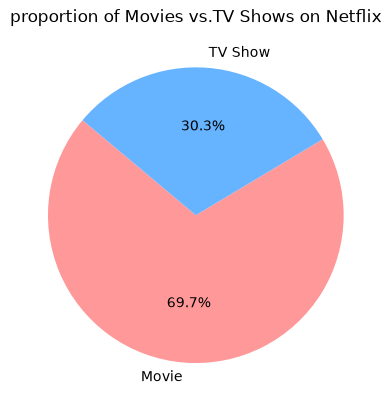

In [49]:
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('proportion of Movies vs.TV Shows on Netflix')
plt.ylabel('')
plt.show()

How has tha content added over the time?

In [52]:
# Group data by year and month content type
content_over_time = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
print(content_over_time)

type               Movie  TV Show
year_added                       
 April 15, 2018      0.0      1.0
 April 16, 2019      0.0      1.0
 April 17, 2016      0.0      1.0
 April 20, 2017      0.0      1.0
 April 4, 2017       0.0      1.0
...                  ...      ...
September 9, 2016    1.0      0.0
September 9, 2018    0.0      1.0
September 9, 2019    1.0      0.0
September 9, 2020    4.0      2.0
September 9, 2021    3.0      1.0

[1765 rows x 2 columns]


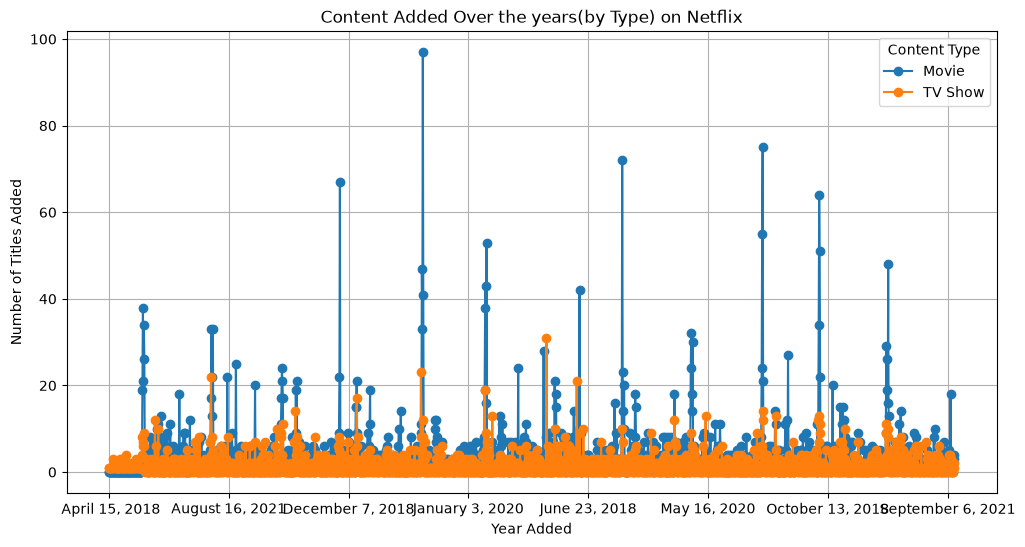

In [58]:
content_over_time.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Content Added Over the years(by Type) on Netflix')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

Insights: By saparating movies and TV Shows, We can clearly see that while both
grew significantly from the year 2008 to 2020, the addition of the movies accelerated more dramatically,especially in the year 2019.
The growth in the TV showshas been more steady. there appear to be slight shutdoen in content addition in the year 2020 and 2021,which could be due to the peack of COVID-19 at that time which might affects the production or may be the dataset could be incomplete for the latest years

What are the popular in genre?

In [60]:
# Split the 'listed_in' column and explode it 
genre = df.assign(genre=df['listed_in'].str.split(',')).explode('genre')
genre

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_aded,year_added,month_added,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,"September 25, 2021","September 25, 2021",Documentaries
1,s2,TV Show,Blood & Water,unkniown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,"September 24, 2021","September 24, 2021",International TV Shows
1,s2,TV Show,Blood & Water,unkniown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,"September 24, 2021","September 24, 2021",TV Dramas
1,s2,TV Show,Blood & Water,unkniown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,"September 24, 2021","September 24, 2021",TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,"September 24, 2021","September 24, 2021",Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020-01-11,"January 11, 2020","January 11, 2020",Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020-01-11,"January 11, 2020","January 11, 2020",Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019-03-02,"March 2, 2019","March 2, 2019",Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019-03-02,"March 2, 2019","March 2, 2019",International Movies


Most Popular Genres

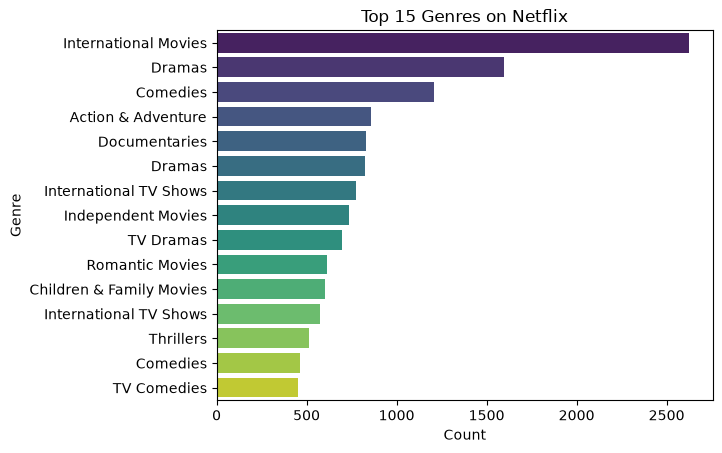

In [61]:
# get the top 15 genres and there counts
top_genres_counts = genre['genre'].value_counts().reset_index()
# Rename columns for clarity
top_genres_counts.columns = ['genre', 'count']

# Select only the top 15 genres for visualization
top_genres_counts_plot = top_genres_counts.head(15)

sns.barplot(x='count', y='genre', data=top_genres_counts_plot, palette='viridis',hue='genre', dodge=False, legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

Insights: Internatinal Movies is the most common genre highlighting the netflix global content strategy. 

Distribution of Content Duration

In [65]:
# Separate movies and TV shows for genre analysis
movies_df= genre[genre['type'] == 'Movie'].copy()
tv_shows_df = genre[genre['type'] == 'TV Show'].copy()

# Clean and convert duration to numeric for movies
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Clean and convert duration to numeric for TV shows (average episode duration)
tv_shows_df['season'] = tv_shows_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)

C:\Users\pc\AppData\Local\Temp\ipykernel_1972\1467071552.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ax=axes[1], data=tv_shows_df, x='season', palette='rocket', bins=30, kde=True, color='salmon').set(title='Distribution of TV Show Seasons on Netflix', xlabel='Number of Seasons', ylabel='Count')


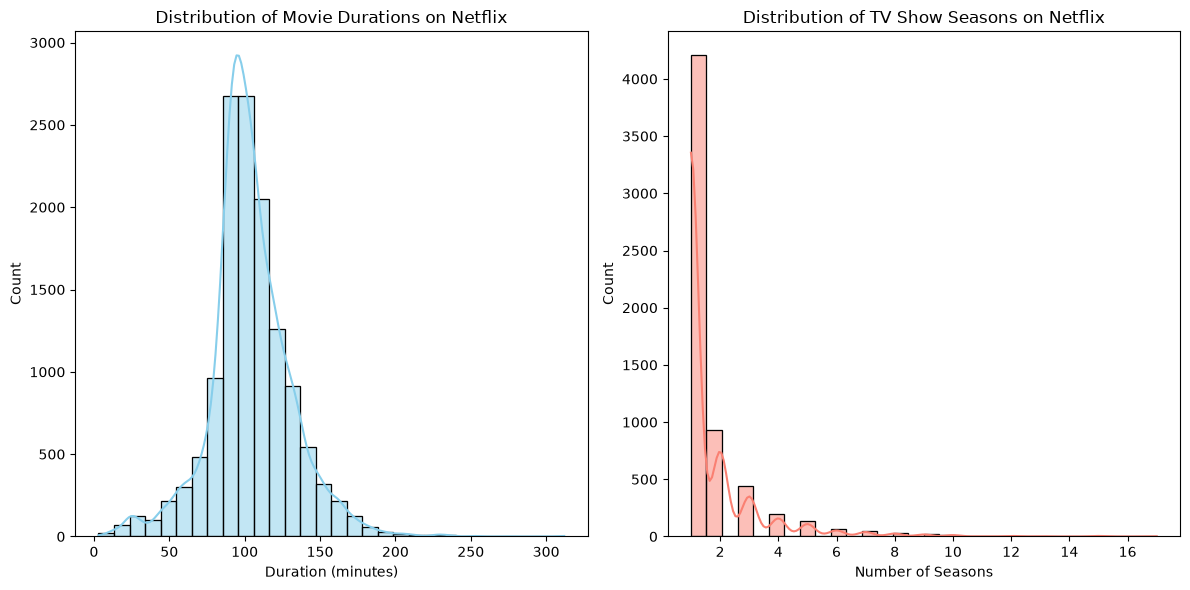

In [71]:
# plot the distribution of movie durations
fig, axes = plt.subplots(1,2,figsize=(12, 6))

# Movie duration distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=30, kde=True, color='skyblue').set(title='Distribution of Movie Durations on Netflix', xlabel='Duration (minutes)', ylabel='Count')

#tv Show season distribution
sns.histplot(ax=axes[1], data=tv_shows_df, x='season', palette='rocket', bins=30, kde=True, color='salmon').set(title='Distribution of TV Show Seasons on Netflix', xlabel='Number of Seasons', ylabel='Count')
plt.tight_layout()
plt.show()

Insights: 

- The mejority of the movies on NEtflix are in the range between 80 to 120 minutes long
 which is ideally the Standard  for any Features film

- The vast majority of the TV shows on netflix are short-lived, with most having only 1 season. This could also reflect a strategy of producing many plot and only reviewing the most successful ones, or a focus on limited series.

Where does the content come from?

In [73]:
# Hnadle the multi Country listing to similar genre analysis
countries = df.assign(country=df['country'].str.split(',')).explode('country')
# get the top 15 countries and there counts
top_country_counts = countries['country'].value_counts().reset_index()
top_country_counts.columns = ['country', 'count']# Rename columns for clarity
print(top_country_counts)

            country  count
0     United States   4031
1             India   1008
2    United Kingdom    627
3     United States    479
4            Canada    271
..              ...    ...
192          Panama      1
193         Namibia      1
194          Uganda      1
195    East Germany      1
196      Montenegro      1

[197 rows x 2 columns]


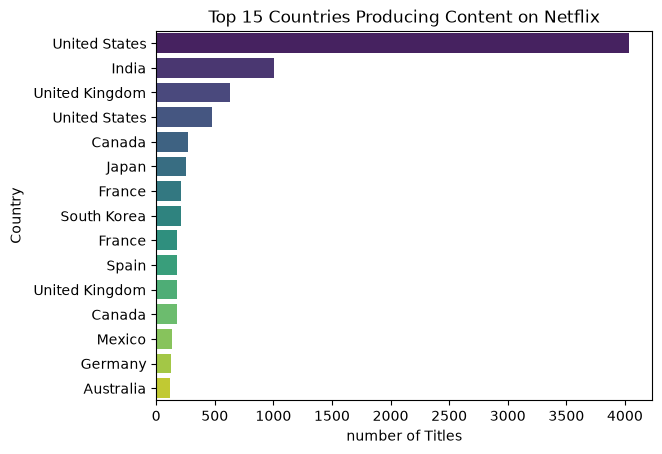

In [76]:
# Select only the top 15 countries for visualization
top_country_counts_plot = top_country_counts.head(15)

sns.barplot(x='count', y='country', data=top_country_counts_plot, palette='viridis',hue='country', dodge=False, legend=False)
plt.title('Top 15 Countries Producing Content on Netflix')
plt.xlabel('number of Titles')
plt.ylabel('Country')
plt.show()

Insights: The USA is by far the largest producer of the content avilable on Netflix
followed by India which somehow expliane that why so many of the top actors were from india

Maturity ratings of the content

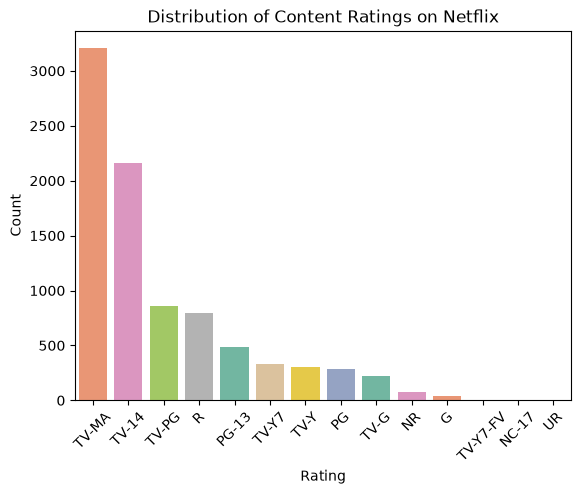

In [77]:
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='Set2',hue='rating', dodge=False, legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insights: A large portion of the netflix content aimed at mature audiences, with TV-MA (Mature Audience) and TV-14 (Parents Stronhly Coutioned) being the two most common ratings.

Freature Engineering

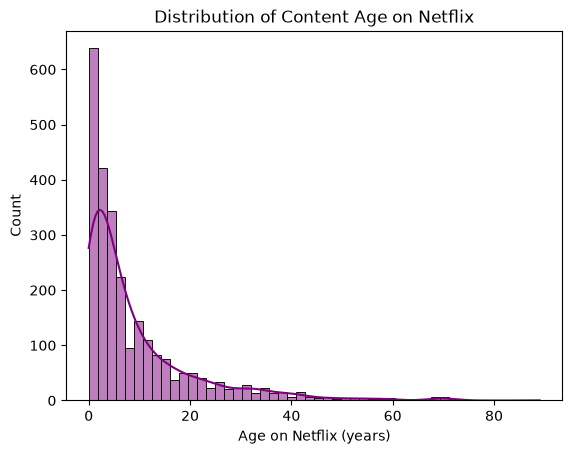

In [81]:
# Create the age_on_netflix' feature 
df['age_on_netflix'] = 2014-df['release_year']
# filter out any potential error where added year is less than release year
content_age = df[df['age_on_netflix'] >= 0]

plot = sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True, color='purple')
plot.set(title='Distribution of Content Age on Netflix', xlabel='Age on Netflix (years)', ylabel='Count')
plt.show()

Insight: A large spike at 0 indecates that the significant amount of the content is being added  in the same year, which is the

multivariate Analysis